In [ ]:
import numpy as np
from numpy import cos, sin, exp, pi,sqrt
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from mpmath import pcfd
from tqdm import tqdm
import sys
sys.path.append("../../../src/")
import kblock_ising_model as kb
import kibble_zurek as kz
from time import time


In [ ]:

#P_n correlations do not calculate connected correlator at all
def P_n_correlations(n,l,state, even = True):
    #Term 1 
    indices = [i for i in range(0,n)]
    #Term 2 
    indices +=[i for i in range(n+l-1,2*n+l-1)]
    terms = kb.all_combinations(indices)
   # print(terms)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = kz.Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))
    #
    dat = []
    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(kz.sigma_general(indices,state))*degen)
        else:
            dat.append(kz.sigma_general(indices,state)*degen)
    dat.append(1)
    #All terms have equal weight. 

    return np.sum(dat)/2**(2*n)#,terms


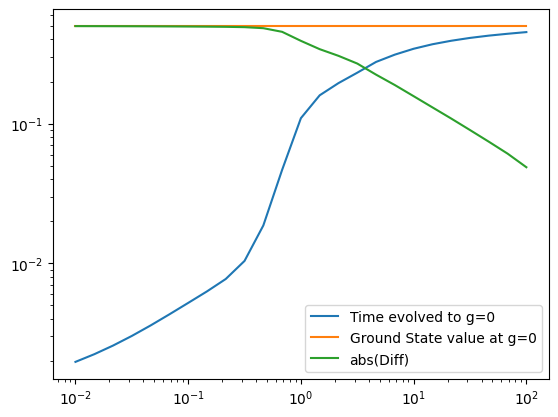

In [3]:
#Simple Test
L = 100
n = 10
taus = np.logspace(-2,2,25)
Kibble_Zurek = []
Ground_State = []
Delta_values = []

for tau in taus:
    t= tau
    state_t = kz.state(L,tau,t)
    k0 = kb.k_vals(L)
    #U0 needs -g because of different conventions
    U0 = kb.U(k0,-kz.g(t,tau))

    P_kz = kz.P_n(n,state_t)
    P0 = kb.P_n(n,U0,k0)
    diff = kz.delta(state_t,[U0,k0],n)

    Kibble_Zurek+= [P_kz]
    Ground_State += [P0]
    Delta_values += [diff]
plot(taus,Kibble_Zurek,label="Time evolved to g=0")
plot(taus,Ground_State,label="Ground State value at g=0")
plot(taus,Delta_values,label="abs(Diff)")
plt.legend()
plt.yscale("log")
plt.xscale("log")

array([[-0.15138557+0.03853004j,  0.24826917-0.37969631j,
         0.14951271-0.69111935j, -0.81296333-0.36508049j,
         0.64659082-0.75344355j],
       [ 0.21977936+0.96296151j, -0.73347676-0.50616694j,
        -0.68715892-0.16677116j, -0.19611761+0.40907793j,
        -0.10536718-0.05604361j],
       [ 0.31415927+0.j        ,  0.9424778 +0.j        ,
         1.57079633+0.j        ,  2.19911486+0.j        ,
         2.82743339+0.j        ]])

In [13]:
###correlator
def delta_data(n,t,tau):
    r_points = np.arange(rmin,rmax)
    ##Definition of connected correlator in a translationally invariant system
    data = array([P_n_correlations(n,r)-P_n(n)**2 for r in tqdm(r_points)])
    return [data,r_points]
import os

folder_name = "States_Data"

# Create the folder if it doesn't exist
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

100%|██████████| 15/15 [9:11:59<00:00, 2207.94s/it]


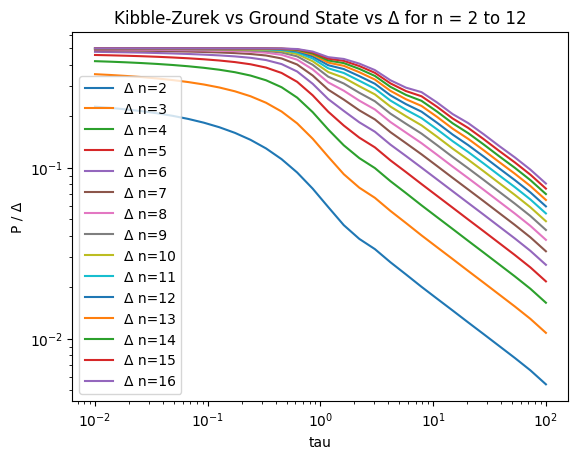

In [ ]:
L = 100
taus = np.logspace(-2, 2, 50)
ns = range(2, 17)


for n in tqdm(ns):
    Kibble_Zurek = []
    Ground_State = []
    Delta_values = []

    for tau in taus:
        t = tau
        state_t = kz.state(L, tau, t)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0, -kz.g(t, tau))

        P_kz = kz.P_n(n, state_t)
        P0 = kb.P_n(n, U0, k0)
        diff = kz.delta(state_t, [U0, k0], n)

        Kibble_Zurek.append(P_kz)
        Ground_State.append(P0)
        Delta_values.append(diff)

   # plot(taus, Kibble_Zurek, label=f"KZ n={n}")
   # plot(taus, Ground_State, label=f"GS n={n}")
    plot(taus, Delta_values, label=f"Δ n={n}")

plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("tau")
plt.ylabel("P / Δ")
plt.title("Kibble-Zurek vs Ground State vs Δ for n = 2 to 12")
plt.show()


In [9]:
Delta_matrix = []

for n in tqdm(ns):
    Delta_values = []

    for tau in taus:
        t = tau
        state_t = kz.state(L, tau, t)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0, -kz.g(t, tau))

        diff = kz.delta(state_t, [U0, k0], n)
        Delta_values.append(diff)

    Delta_matrix.append(Delta_values)

Delta_matrix = np.array(Delta_matrix)  # shape (len(ns), len(taus))


100%|██████████| 8/8 [00:10<00:00,  1.34s/it]


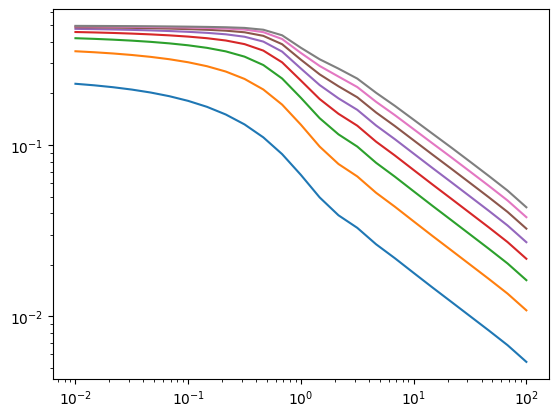

In [41]:
plt.loglog(taus,Delta_matrix.T)

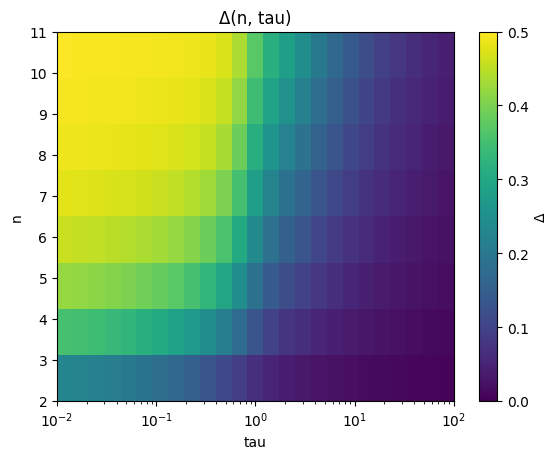

In [61]:
tau_edges = np.geomspace(taus[0], taus[-1], Delta_matrix.shape[1] + 1)  # len=26
n_edges = np.linspace(ns[0], ns[-1], Delta_matrix.shape[0] + 1)  # len=9
plt.pcolormesh(tau_edges, n_edges, Delta_matrix, shading='auto', vmin=0, vmax=0.5)
plt.xscale('log')
plt.xlabel("tau")
plt.ylabel("n")
plt.colorbar(label="Δ")
plt.title("Δ(n, tau)")
plt.show()


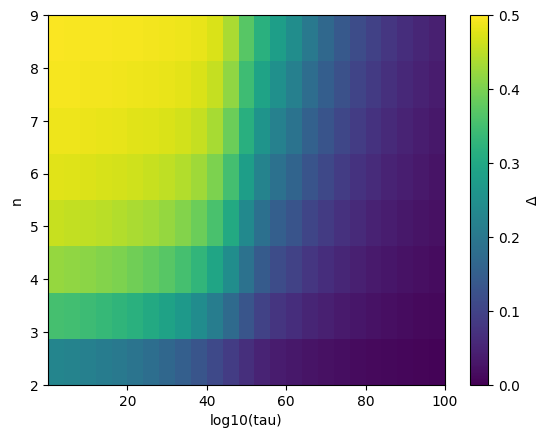

In [43]:
kb.U

<function kblock_ising_model.U(k, g)>

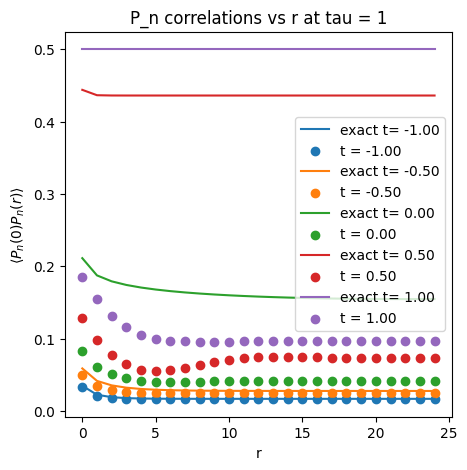

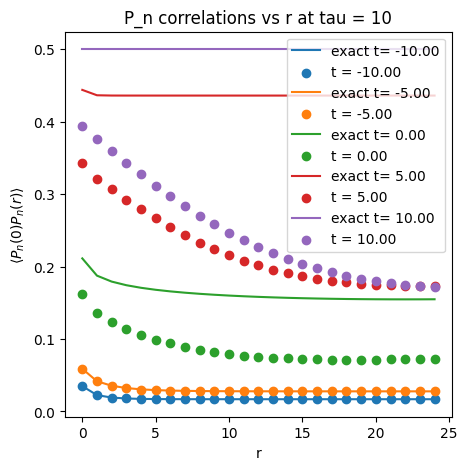

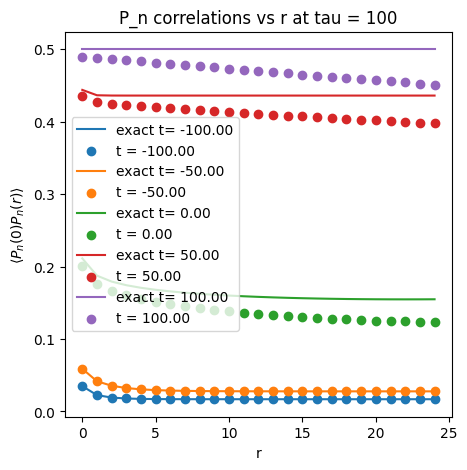

In [50]:
import matplotlib.pyplot as plt

L = 50
taus = [1, 10, 100]
r = np.arange(0, 25)

for tau in taus:
    t = np.linspace(-tau, tau, 25)
    data = np.zeros((len(t), len(r)))
    exact= np.zeros((len(t), len(r)))

    for ti in range(len(t)):
        state = kz.state(L, tau, t[ti])
        g0 = kz.g(t[ti],tau)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0,g0)
        for ri in range(len(r)):
            exact[ti,ri]= kb.P_n_correlations(4,r[ri],U0,k0)
            data[ti, ri] = P_n_correlations(4, r[ri], state)

    # Plot correlation vs. r for a few selected times (e.g., start, middle, end)
    plt.figure(figsize=(5,5))
    for ti in [0, len(t)//4, len(t)//2,len(t)//4*3, -1]:
        plt.plot(r,exact[ti],label=f"exact t= {t[ti]:.2f}")
        plt.scatter(r, data[ti], label=f"t = {t[ti]:.2f}")
    plt.title(f"P_n correlations vs r at tau = {tau}")
    plt.xlabel("r")
    plt.ylabel(r"$\langle P_n(0) P_n(r) \rangle$")
    plt.legend()
    plt.show()


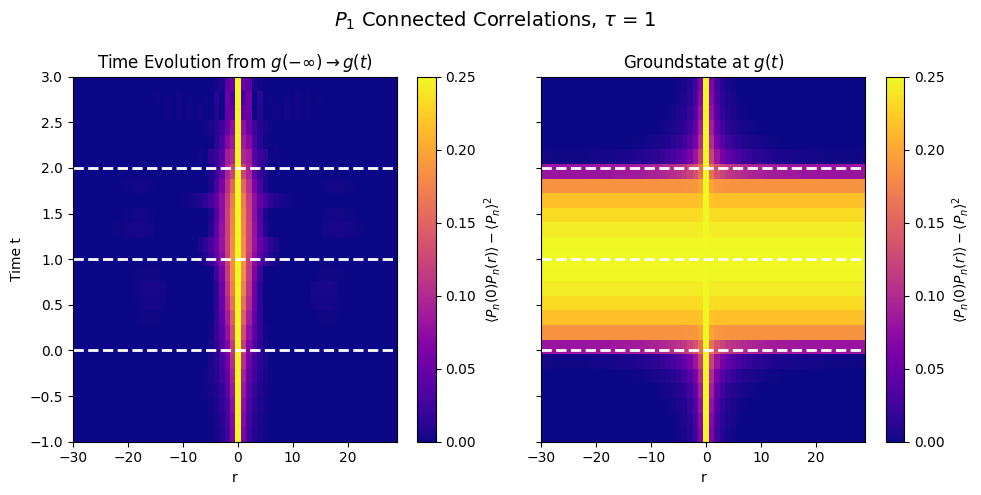

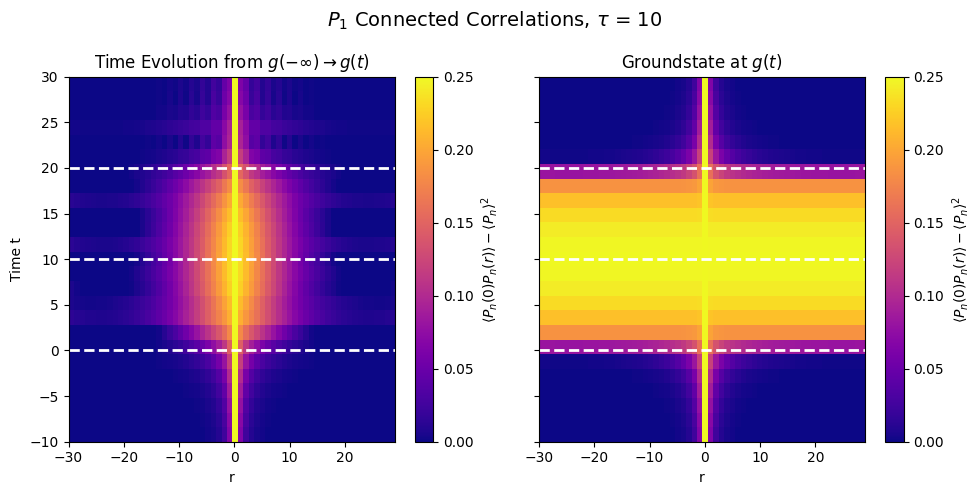

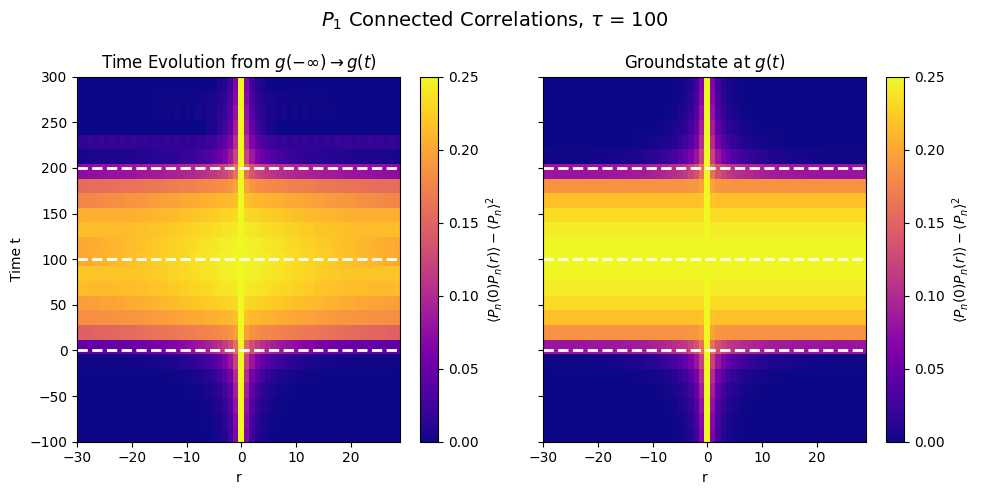

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

L = 50
taus = [1, 10, 100]
r = np.arange(-30, 30)
n = 1
for tau in taus:
    t = np.linspace(-1*tau, 3*tau, 25)
    data = np.zeros((len(t), len(r)))
    exact = np.zeros((len(t), len(r)))

    for ti in range(len(t)):
        state = kz.state(L, tau, t[ti])
        g0 = kz.g(t[ti], tau)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0, -g0)
        for ri in range(len(r)):
            exact[ti, ri] = kb.P_n_correlations(n, r[ri], U0, k0) - kb.P_n(n, U0, k0)**2
            data[ti, ri] = P_n_correlations(n, r[ri], state) - kz.P_n(n, state)**2

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    im0 = axes[0].imshow(data, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[0].set_title(r"Time Evolution from $g(-\infty ) \to g(t) $")
    axes[0].set_xlabel("r")
    axes[0].set_ylabel("Time t")
    axes[0].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)
    #axes[0].hlines(tau,r[0],r[-1],color="white")
   # axes[0].hlines(2*tau,r[0],r[-1],color="white")
    fig.colorbar(im0, ax=axes[0], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    im1 = axes[1].imshow(exact, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[1].set_title(r"Groundstate at $g(t)$")
    axes[1].set_xlabel("r")
    axes[1].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)

    fig.colorbar(im1, ax=axes[1], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    fig.suptitle(rf"$P_{n}$ Connected Correlations, $\tau$ = {tau}", fontsize=14)
    plt.tight_layout()
    plt.show()


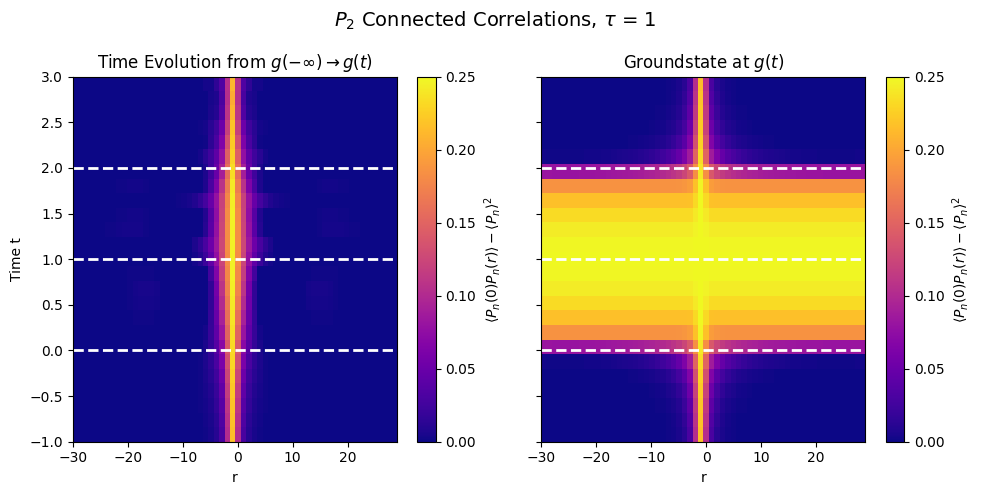

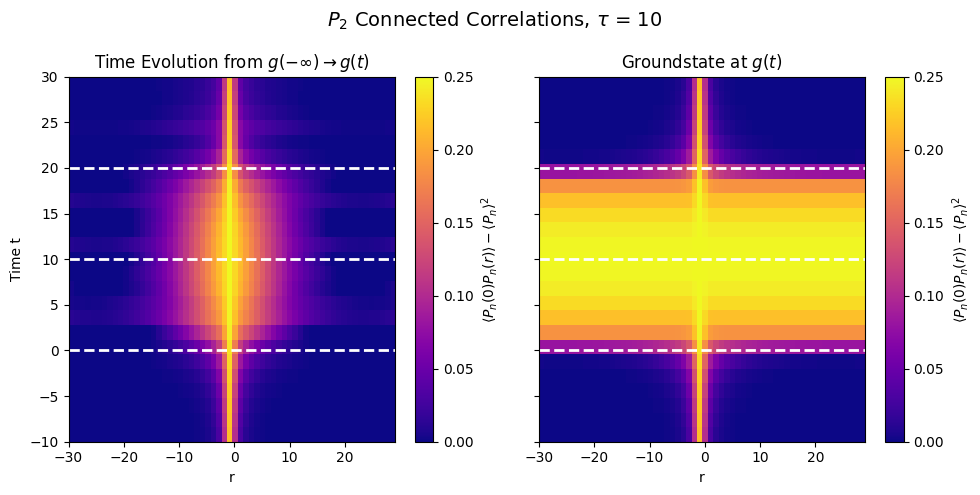

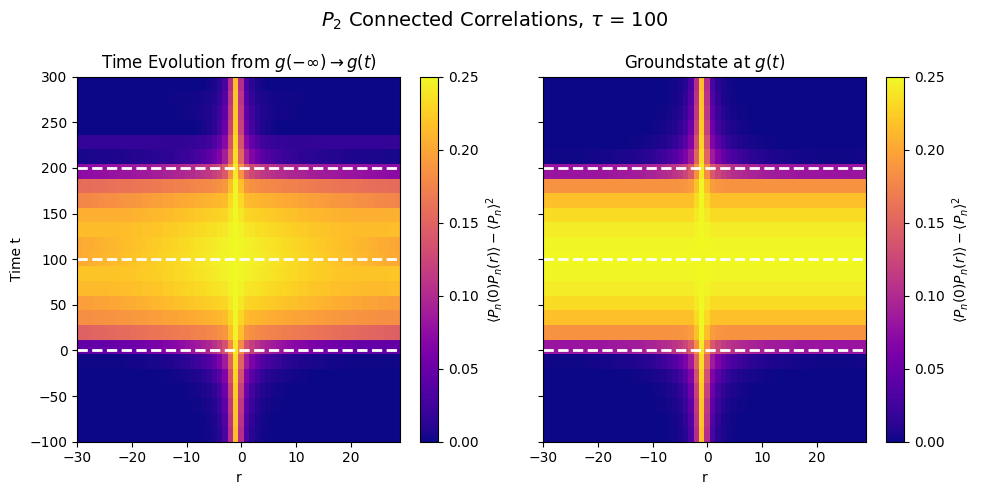

In [94]:
import matplotlib.pyplot as plt
import numpy as np

L = 50
taus = [1, 10, 100]
r = np.arange(-30, 30)
n = 2
for tau in taus:
    t = np.linspace(-1*tau, 3*tau, 25)
    data = np.zeros((len(t), len(r)))
    exact = np.zeros((len(t), len(r)))

    for ti in range(len(t)):
        state = kz.state(L, tau, t[ti])
        g0 = kz.g(t[ti], tau)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0, -g0)
        for ri in range(len(r)):
            exact[ti, ri] = kb.P_n_correlations(n, r[ri], U0, k0) - kb.P_n(n, U0, k0)**2
            data[ti, ri] = P_n_correlations(n, r[ri], state) - kz.P_n(n, state)**2

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    im0 = axes[0].imshow(data, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[0].set_title(r"Time Evolution from $g(-\infty ) \to g(t) $")
    axes[0].set_xlabel("r")
    axes[0].set_ylabel("Time t")
    axes[0].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)
    #axes[0].hlines(tau,r[0],r[-1],color="white")
   # axes[0].hlines(2*tau,r[0],r[-1],color="white")
    fig.colorbar(im0, ax=axes[0], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    im1 = axes[1].imshow(exact, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[1].set_title(r"Groundstate at $g(t)$")
    axes[1].set_xlabel("r")
    axes[1].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)

    fig.colorbar(im1, ax=axes[1], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    fig.suptitle(rf"$P_{n}$ Connected Correlations, $\tau$ = {tau}", fontsize=14)
    plt.tight_layout()
    plt.show()


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


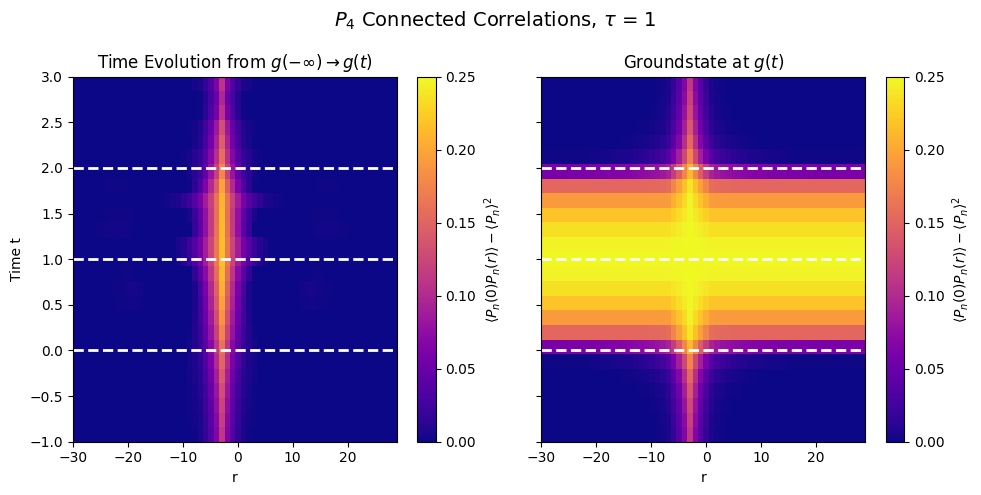

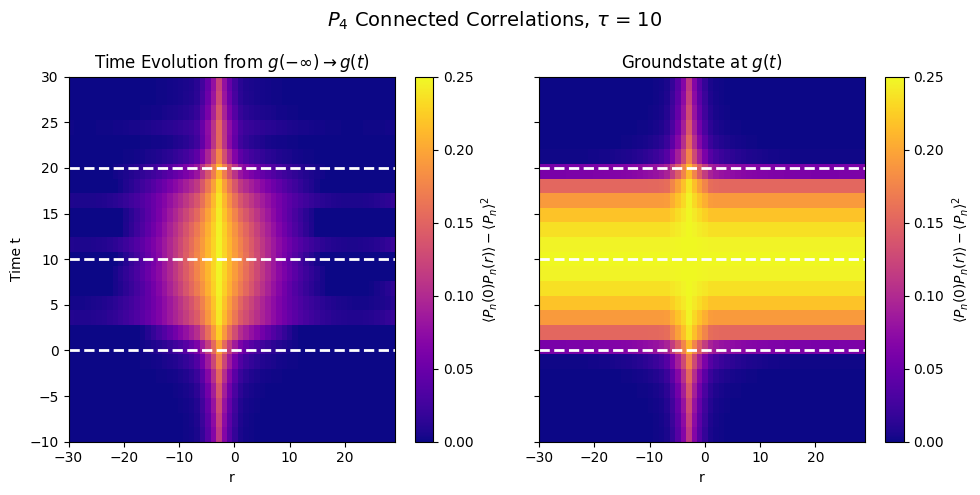

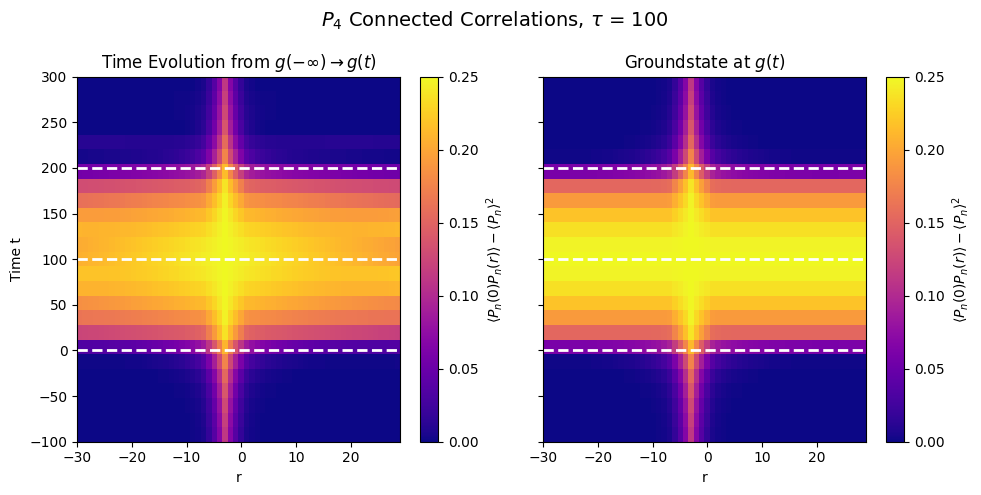

In [95]:
import matplotlib.pyplot as plt
import numpy as np

L = 50
taus = [1, 10, 100]
r = np.arange(-30, 30)
n = 4
for tau in taus:
    t = np.linspace(-1*tau, 3*tau, 25)
    data = np.zeros((len(t), len(r)))
    exact = np.zeros((len(t), len(r)))

    for ti in range(len(t)):
        state = kz.state(L, tau, t[ti])
        g0 = kz.g(t[ti], tau)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0, -g0)
        for ri in range(len(r)):
            exact[ti, ri] = kb.P_n_correlations(n, r[ri], U0, k0) - kb.P_n(n, U0, k0)**2
            data[ti, ri] = P_n_correlations(n, r[ri], state) - kz.P_n(n, state)**2

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    im0 = axes[0].imshow(data, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[0].set_title(r"Time Evolution from $g(-\infty ) \to g(t) $")
    axes[0].set_xlabel("r")
    axes[0].set_ylabel("Time t")
    axes[0].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)
    #axes[0].hlines(tau,r[0],r[-1],color="white")
   # axes[0].hlines(2*tau,r[0],r[-1],color="white")
    fig.colorbar(im0, ax=axes[0], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    im1 = axes[1].imshow(exact, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[1].set_title(r"Groundstate at $g(t)$")
    axes[1].set_xlabel("r")
    axes[1].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)

    fig.colorbar(im1, ax=axes[1], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    fig.suptitle(rf"$P_{n}$ Connected Correlations, $\tau$ = {tau}", fontsize=14)
    plt.tight_layout()
    plt.show()


/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:147: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


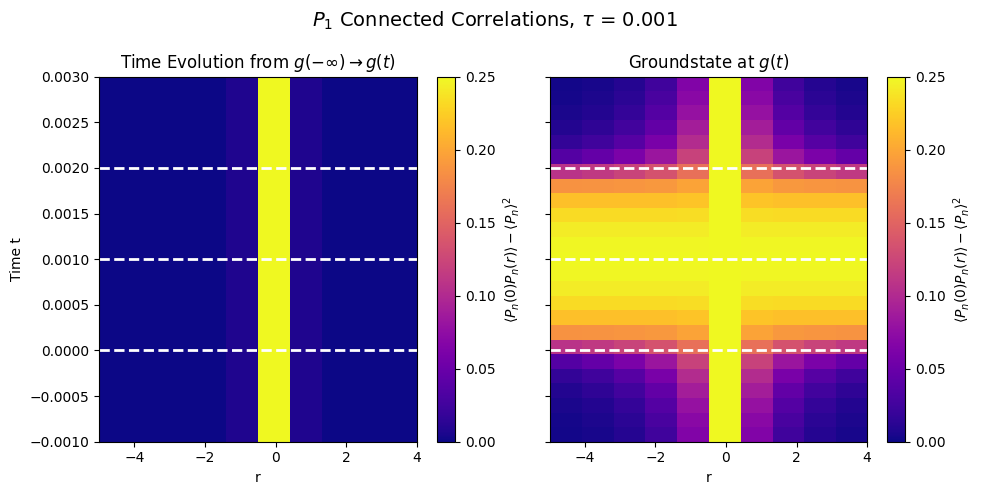

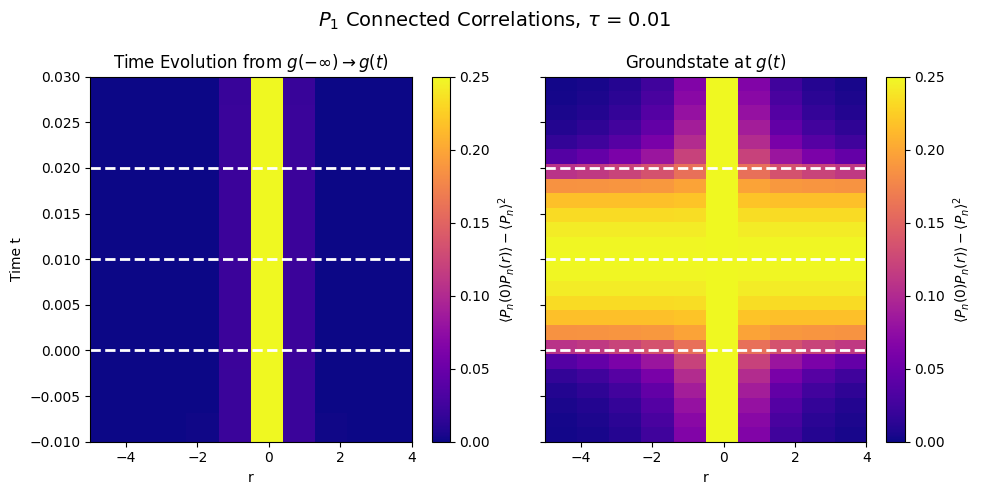

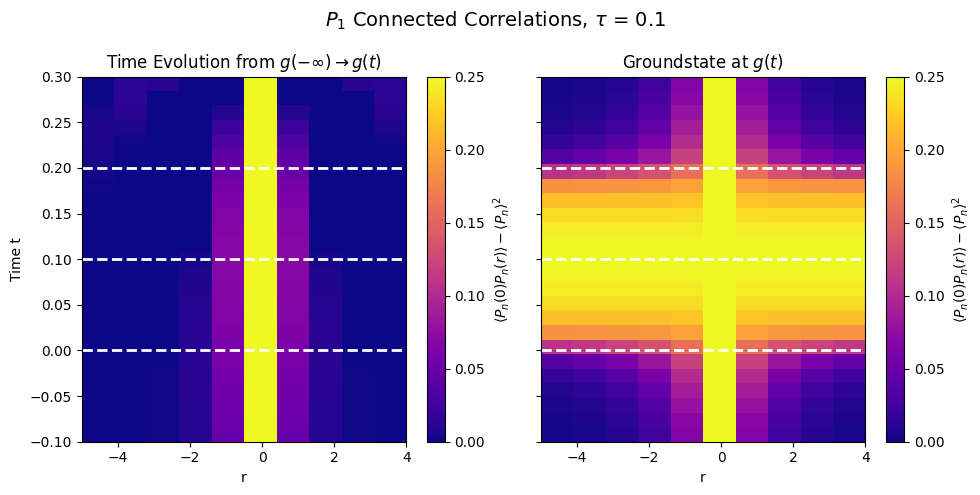

In [96]:
import matplotlib.pyplot as plt
import numpy as np

L = 50
taus = [.001, .010,.1]
r = np.arange(-5, 5)
n = 1
for tau in taus:
    t = np.linspace(-1*tau, 3*tau, 25)
    data = np.zeros((len(t), len(r)))
    exact = np.zeros((len(t), len(r)))

    for ti in range(len(t)):
        state = kz.state(L, tau, t[ti])
        g0 = kz.g(t[ti], tau)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0, -g0)
        for ri in range(len(r)):
            exact[ti, ri] = kb.P_n_correlations(n, r[ri], U0, k0) - kb.P_n(n, U0, k0)**2
            data[ti, ri] = P_n_correlations(n, r[ri], state) - kz.P_n(n, state)**2

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    im0 = axes[0].imshow(data, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[0].set_title(r"Time Evolution from $g(-\infty ) \to g(t) $")
    axes[0].set_xlabel("r")
    axes[0].set_ylabel("Time t")
    axes[0].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)
    #axes[0].hlines(tau,r[0],r[-1],color="white")
   # axes[0].hlines(2*tau,r[0],r[-1],color="white")
    fig.colorbar(im0, ax=axes[0], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    im1 = axes[1].imshow(exact, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[1].set_title(r"Groundstate at $g(t)$")
    axes[1].set_xlabel("r")
    axes[1].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)

    fig.colorbar(im1, ax=axes[1], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    fig.suptitle(rf"$P_{n}$ Connected Correlations, $\tau$ = {tau}", fontsize=14)
    plt.tight_layout()
    plt.show()


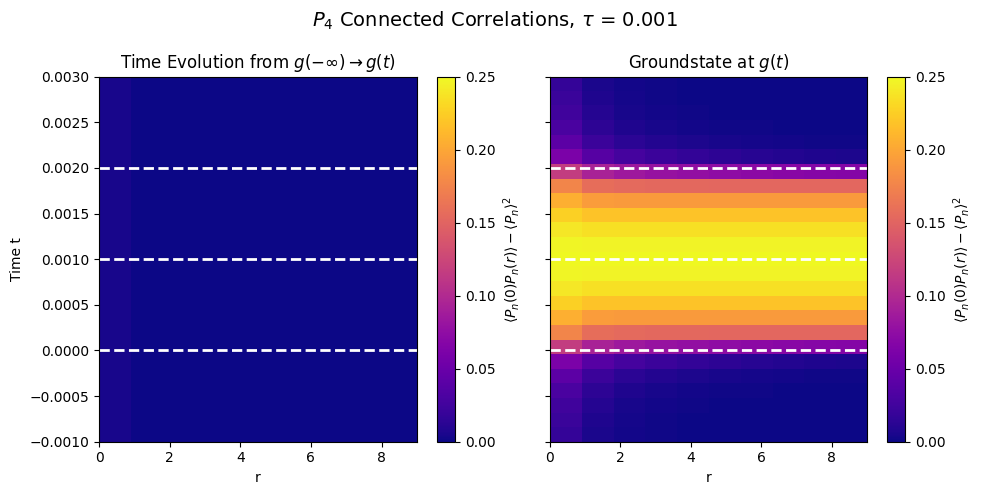

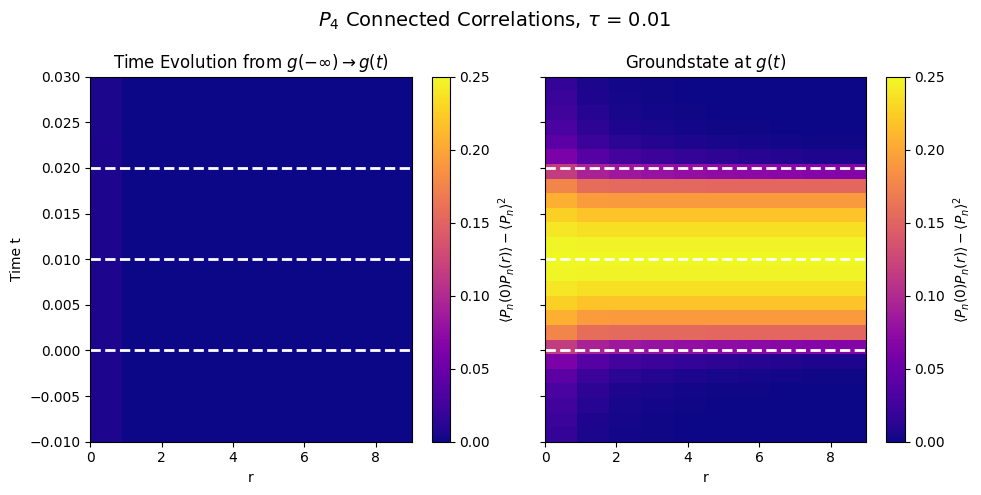

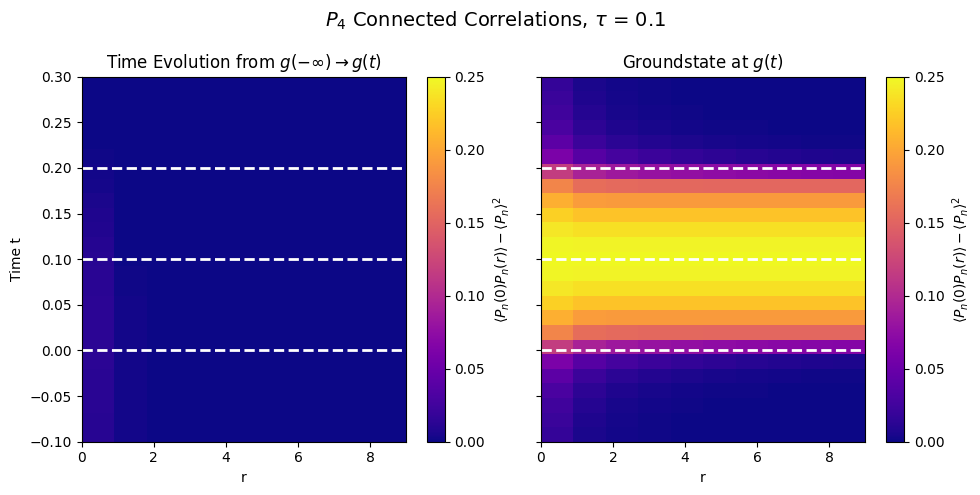

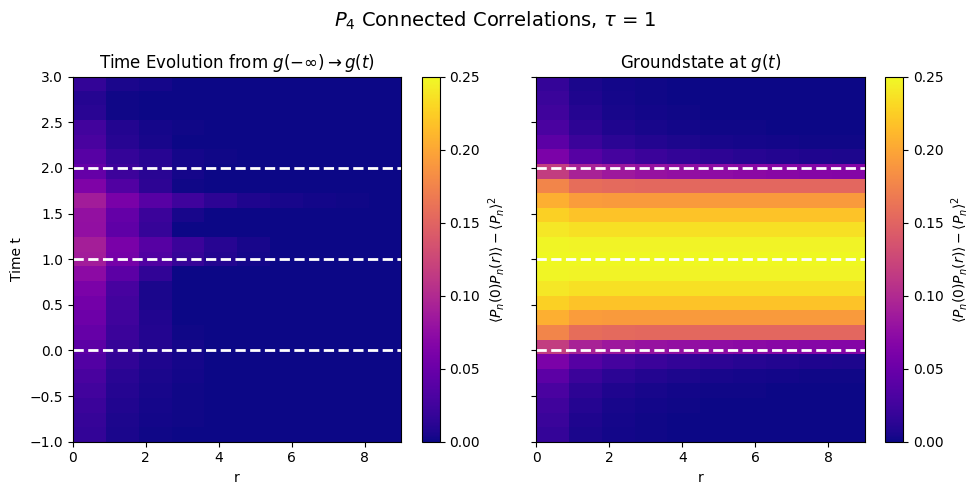

In [100]:
import matplotlib.pyplot as plt
import numpy as np

L = 50
taus = [.001, .010,.1,1]
r = np.arange(0, 10)
n = 4
for tau in taus:
    t = np.linspace(-1*tau, 3*tau, 25)
    data = np.zeros((len(t), len(r)))
    exact = np.zeros((len(t), len(r)))

    for ti in range(len(t)):
        state = kz.state(L, tau, t[ti])
        g0 = kz.g(t[ti], tau)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0, -g0)
        for ri in range(len(r)):
            exact[ti, ri] = kb.P_n_correlations(n, r[ri], U0, k0) - kb.P_n(n, U0, k0)**2
            data[ti, ri] = P_n_correlations(n, r[ri], state) - kz.P_n(n, state)**2

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    im0 = axes[0].imshow(data, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[0].set_title(r"Time Evolution from $g(-\infty ) \to g(t) $")
    axes[0].set_xlabel("r")
    axes[0].set_ylabel("Time t")
    axes[0].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)
    #axes[0].hlines(tau,r[0],r[-1],color="white")
   # axes[0].hlines(2*tau,r[0],r[-1],color="white")
    fig.colorbar(im0, ax=axes[0], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    im1 = axes[1].imshow(exact, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[1].set_title(r"Groundstate at $g(t)$")
    axes[1].set_xlabel("r")
    axes[1].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)

    fig.colorbar(im1, ax=axes[1], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    fig.suptitle(rf"$P_{n}$ Connected Correlations, $\tau$ = {tau}", fontsize=14)
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

L = 50
taus = [.001, .010,.1]
r = np.arange(-5, 5)
n = 2
for tau in taus:
    t = np.linspace(-1*tau, 3*tau, 25)
    data = np.zeros((len(t), len(r)))
    exact = np.zeros((len(t), len(r)))

    for ti in range(len(t)):
        state = kz.state(L, tau, t[ti])
        g0 = kz.g(t[ti], tau)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0, -g0)
        for ri in range(len(r)):
            exact[ti, ri] = kb.P_n_correlations(n, r[ri], U0, k0) - kb.P_n(n, U0, k0)**2
            data[ti, ri] = P_n_correlations(n, r[ri], state) - kz.P_n(n, state)**2

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    im0 = axes[0].imshow(data, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[0].set_title(r"Time Evolution from $g(-\infty ) \to g(t) $")
    axes[0].set_xlabel("r")
    axes[0].set_ylabel("Time t")
    axes[0].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)
    #axes[0].hlines(tau,r[0],r[-1],color="white")
   # axes[0].hlines(2*tau,r[0],r[-1],color="white")
    fig.colorbar(im0, ax=axes[0], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    im1 = axes[1].imshow(exact, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[1].set_title(r"Groundstate at $g(t)$")
    axes[1].set_xlabel("r")
    axes[1].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)

    fig.colorbar(im1, ax=axes[1], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    fig.suptitle(rf"$P_{n}$ Connected Correlations, $\tau$ = {tau}", fontsize=14)
    plt.tight_layout()
    plt.show()


/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:147: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


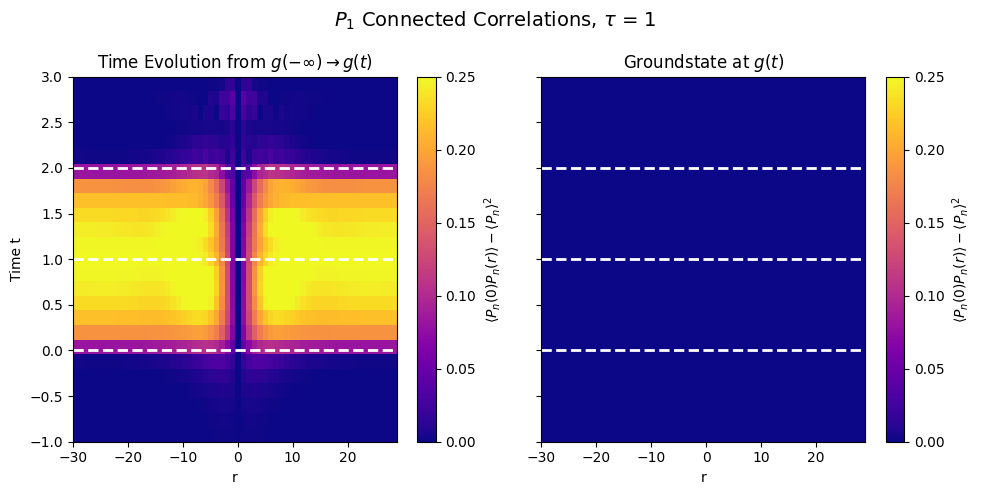

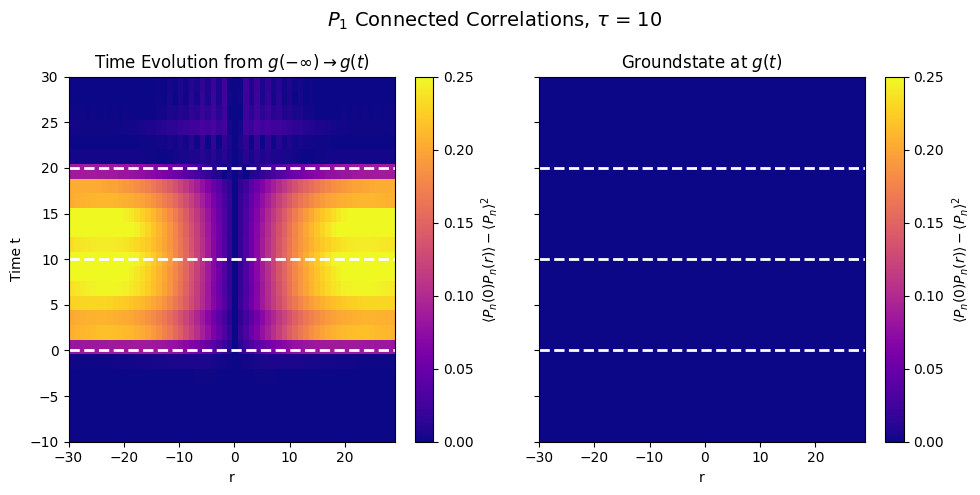

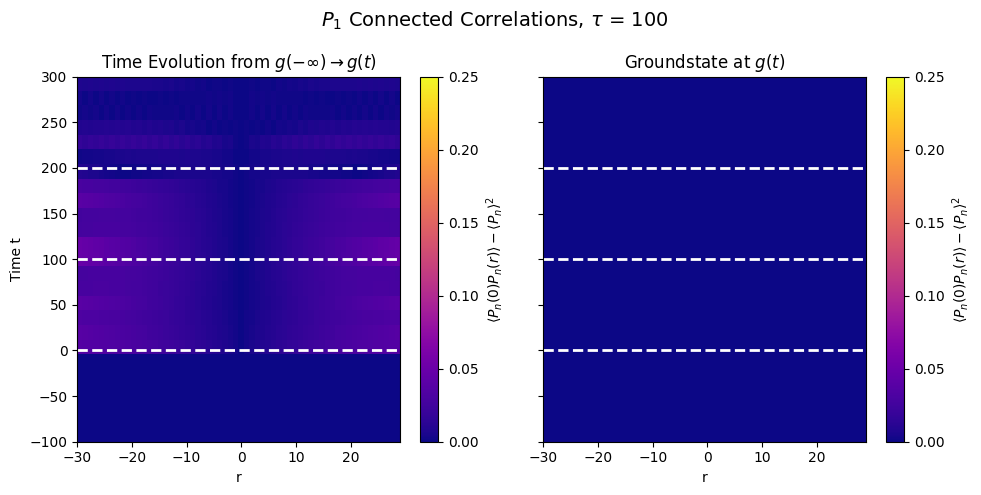

In [101]:
import matplotlib.pyplot as plt
import numpy as np

L = 50
taus = [1, 10, 100]
r = np.arange(-30, 30)
n = 1
for tau in taus:
    t = np.linspace(-1*tau, 3*tau, 25)
    data = np.zeros((len(t), len(r)))
    exact = np.zeros((len(t), len(r)))

    for ti in range(len(t)):
        state = kz.state(L, tau, t[ti])
        g0 = kz.g(t[ti], tau)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0, -g0)
        for ri in range(len(r)):
            A = kb.P_n_correlations(n, r[ri], U0, k0) - kb.P_n(n, U0, k0)**2
            B = P_n_correlations(n, r[ri], state) - kz.P_n(n, state)**2
            data[ti,ri] = abs(A-B)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    im0 = axes[0].imshow(data, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[0].set_title(r"Time Evolution from $g(-\infty ) \to g(t) $")
    axes[0].set_xlabel("r")
    axes[0].set_ylabel("Time t")
    axes[0].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)
    #axes[0].hlines(tau,r[0],r[-1],color="white")
   # axes[0].hlines(2*tau,r[0],r[-1],color="white")
    fig.colorbar(im0, ax=axes[0], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    im1 = axes[1].imshow(exact, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[1].set_title(r"Groundstate at $g(t)$")
    axes[1].set_xlabel("r")
    axes[1].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)

    fig.colorbar(im1, ax=axes[1], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    fig.suptitle(rf"$P_{n}$ Connected Correlations, $\tau$ = {tau}", fontsize=14)
    plt.tight_layout()
    plt.show()


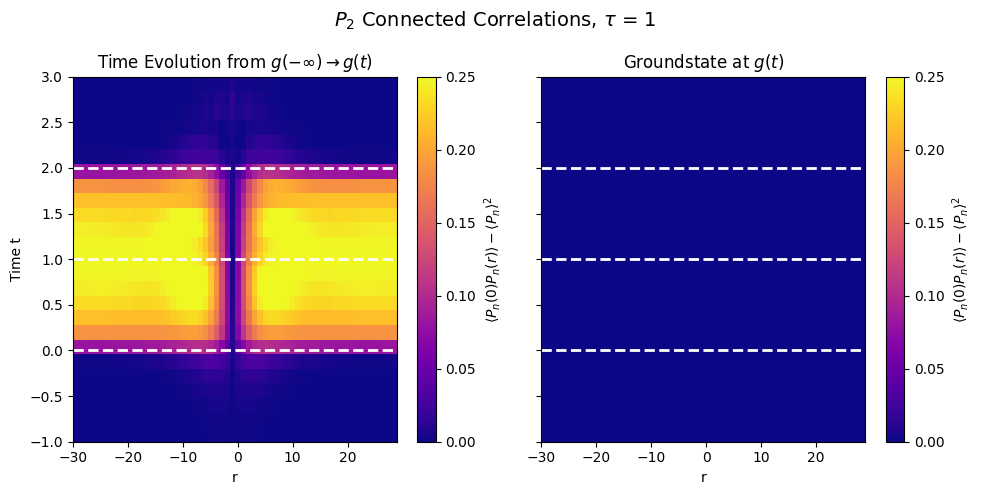

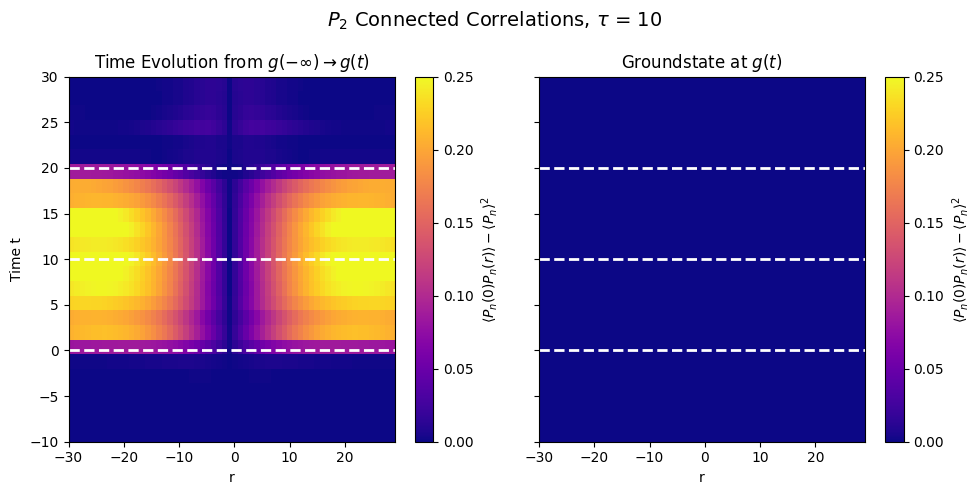

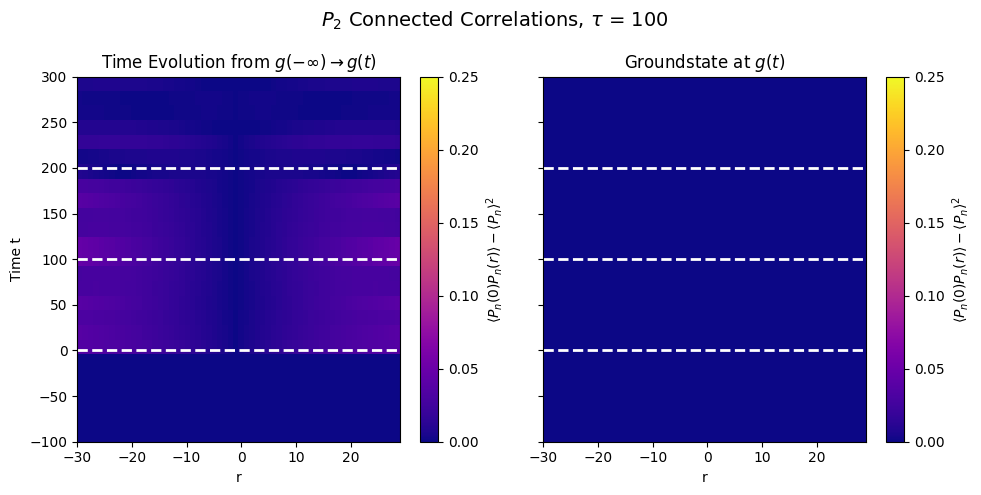

In [102]:
import matplotlib.pyplot as plt
import numpy as np

L = 50
taus = [1, 10, 100]
r = np.arange(-30, 30)
n = 2
for tau in taus:
    t = np.linspace(-1*tau, 3*tau, 25)
    data = np.zeros((len(t), len(r)))
    exact = np.zeros((len(t), len(r)))

    for ti in range(len(t)):
        state = kz.state(L, tau, t[ti])
        g0 = kz.g(t[ti], tau)
        k0 = kb.k_vals(L)
        U0 = kb.U(k0, -g0)
        for ri in range(len(r)):
            A = kb.P_n_correlations(n, r[ri], U0, k0) - kb.P_n(n, U0, k0)**2
            B = P_n_correlations(n, r[ri], state) - kz.P_n(n, state)**2
            data[ti,ri] = abs(A-B)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    im0 = axes[0].imshow(data, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[0].set_title(r"Time Evolution from $g(-\infty ) \to g(t) $")
    axes[0].set_xlabel("r")
    axes[0].set_ylabel("Time t")
    axes[0].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)
    #axes[0].hlines(tau,r[0],r[-1],color="white")
   # axes[0].hlines(2*tau,r[0],r[-1],color="white")
    fig.colorbar(im0, ax=axes[0], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    im1 = axes[1].imshow(exact, aspect='auto', extent=[r[0], r[-1], t[0], t[-1]],
                         origin='lower', cmap='plasma', vmin=0.0, vmax=0.25)
    axes[1].set_title(r"Groundstate at $g(t)$")
    axes[1].set_xlabel("r")
    axes[1].hlines([0,tau,2*tau],r[0],r[-1],color="white",linestyle="--",lw=2)

    fig.colorbar(im1, ax=axes[1], label=r"$\langle P_n(0) P_n(r) \rangle - \langle P_n \rangle^2$")

    fig.suptitle(rf"$P_{n}$ Connected Correlations, $\tau$ = {tau}", fontsize=14)
    plt.tight_layout()
    plt.show()
